# N4SID offset-free MPC — CSTR–separator (square 4x4)

Closed-loop copy of `Parsim_K_10.ipynb` (Kalman filter, target QP, linear MPC). This is **not** a Koopman / CT controller: there is no lifting network, encoder, or `matrix_C` model.

The prediction model is the linear PARSIM-K state-space fit from `CSTRseparator4x4/Identification/hpo_sippy_cl.py` trial 117 (`A,B,C,D` with `D = 0`; n=15, SS_f=20, SS_p=30, MeanVal, B_reval), identified on the same data and scalers as the CSTR–separator notebooks. Files are `*_cstr_separator_sippy_hpo.npy` — not a Koopman model.

**Run this notebook from `CSTRseparator4x4/Control`** so `sim_setup.pkl` is found by the helper QPs. Generate the pickle first:

```bash
python setup.py
```

## Industrial scenario

Two CSTRs in series with a flash separator and recycle (Liu / Li & Swartz). Product quality is bottoms **xB3**; **T1, T2, T3** are regulated temperatures. Manipulated variables: **Q1, Q2, Q3, F10**; the recycle **Fr** and the vessel-2 feed **F20** are fixed (not manipulated), making this a square (4 inputs, 4 outputs) plant.

| Phase | Samples | What happens |
|---|---|---|
| Hold nominal | 0–350 | Li & Swartz steady state |
| Grade change | 350–1000 | Higher-xB3 “premium B” grade (cooler, higher F10) |
| Cold feed | k = 600 | Unmeasured **T10**: 313 → 311 K |
| Lean feed | k = 850 | Unmeasured **xA10**: 1.00 → 0.98 |
| Return | 1000–end | Back to nominal grade; feed upsets stay on |

Disturbances are softened relative to the 6-input plant (which used 310 K / 0.97) because there are two fewer manipulated inputs to reject them; see `feasibility_check()` in `setup.py`. Disturbances are plant-parameter changes only. Observer, target, and MPC are unchanged and reject them through the output-disturbance estimate.

In [6]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import joblib
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from tqdm import tqdm

HERE = Path.cwd().resolve()
REPO_ROOT = HERE.parent.parent
DATA_DIR = HERE.parent / "data"
SRC_PATH = REPO_ROOT / "src"
if SRC_PATH.as_posix() not in sys.path:
    sys.path.append(SRC_PATH.as_posix())
if HERE.as_posix() not in sys.path:
    sys.path.append(HERE.as_posix())

import helper
import plant_inference

In [7]:
plant_inference.init()
scaler, scalerU = plant_inference.scaler, plant_inference.scalerU

# PARSIM-K from sippy CL HPO trial 117 (n=15, SS_f=20, SS_p=30, MeanVal, B_reval). Not a Koopman/CT model.
A = np.load((DATA_DIR / "A_cstr_separator_sippy_hpo.npy").as_posix())
B = np.load((DATA_DIR / "B_cstr_separator_sippy_hpo.npy").as_posix())
C = np.load((DATA_DIR / "C_cstr_separator_sippy_hpo.npy").as_posix())

nz, nu = B.shape
ny = C.shape[0]
nd = ny
print(f"N4SID model  A {A.shape}  B {B.shape}  C {C.shape}  rho(A)={np.max(np.abs(np.linalg.eigvals(A))):.4f}")

T_real, A_block = helper.ident.real_block_diagonalize(A)
A_transformed = inv(T_real) @ A @ T_real
print("Close to block diagonal?", np.allclose(A_block, A_transformed, atol=1e-6))
print("Backtransformation equals A?", np.allclose(A, T_real @ A_block @ inv(T_real), atol=1e-6))

A = inv(T_real) @ A @ T_real
B = inv(T_real) @ B
C = C @ T_real

loaded_setup = joblib.load("sim_setup.pkl")
y_names = loaded_setup["y_names"]
u_names = loaded_setup["u_names"]
Ts = float(loaded_setup["Ts"])

N4SID model  A (6, 6)  B (6, 4)  C (4, 6)  rho(A)=0.9865
Close to block diagonal? True
Backtransformation equals A? True


In [8]:
y_start = loaded_setup["y_start"]
y_start_ns = loaded_setup["y_start_ns"]
reference = loaded_setup["reference"]
reference_ns = loaded_setup["reference_ns"]
y_setpoint = reference[:, 0]
u_previous = loaded_setup["u_previous"]
u_sp = loaded_setup["reference_u"]

z_est_ = np.hstack(((np.linalg.pinv(C) @ y_start.T).T, np.zeros((1, nd))))
P0 = np.eye(nz + nd) * loaded_setup["P0"]
Q = np.block(
    [
        [np.eye(nz) * loaded_setup["Q"], np.zeros((nz, nd))],
        [np.zeros((nd, nz)), np.eye(nd) * loaded_setup["Qd"]],
    ]
)
R = np.eye(ny) * loaded_setup["R"]
Cd = np.eye(ny)
Bd = np.zeros((nz, nd))

A_ = np.block([[A, Bd], [np.zeros((nd, nz)), np.eye(nd)]])
B_ = np.vstack([B, np.zeros((nd, nu))])
C_ = np.hstack([C, Cd])
KF = helper.KF(A_, B_, C_, z_est_, P0, Q, R)
plant_inference.warmup_observer(
    np.asarray(u_previous).reshape(-1),
    lambda u, y: KF.step(u, y),
    loaded_setup["x_start"],
)
z_est_ = np.asarray(KF.x, dtype=float).reshape(1, -1)
print(
    f"KF warmup {plant_inference.KF_WARMUP_STEPS} SS steps; "
    f"d_est={z_est_[0, nz:]}"
)

target_estimation = helper.TargetEstimation(
    A, B, C, loaded_setup["Qy"], loaded_setup["Qu_te"], Bd, Cd
)
z_s, y_s, u_s = target_estimation.get_target(z_est_[:, nz:], y_setpoint, u_sp)
z_ref = z_s
print("Initial target y error (scaled):", y_s - y_setpoint)

Qx = C.T @ loaded_setup["Qy"] @ C + 2e-8 * np.eye(A.shape[0])
print("Qx PSD?", np.all(np.linalg.eigvalsh(Qx) >= -1e-10))
print("Qu PSD?", np.all(np.linalg.eigvalsh(loaded_setup["Qu"]) >= -1e-10))
# loaded_setup["Qu"] = np.diag([0.2, 0.2, 0.2, 0.5, 0.5, 0.5])
mpc = helper.MPC(A, B, C, loaded_setup["Qy"], loaded_setup["Qu"], loaded_setup["Qdu"], Bd, Cd)
mpc.build_problem(Qx)
_ = mpc.get_u_optimal(z_est_[:, :nz], z_est_[:, nz:], u_s, u_previous, z_ref)

sim_time = int(loaded_setup["sim_time"])
plant_inference.reset(loaded_setup["x_start"], Ts=Ts)

KF warmup 1000 SS steps; d_est=[-0.40859141 -0.3649397  -0.38930585  0.34448815]
Initial target y error (scaled): [-8.67631300e-10  1.48699582e-08 -1.43355479e-08 -4.18722834e-11]
Qx PSD? True
Qu PSD? True


In [9]:
z_sim = np.zeros((nz + nd, sim_time + 1))
y_sim = np.zeros((ny, sim_time + 1))
u_sim = np.zeros((nu, sim_time))
us_sim = np.zeros((nu, sim_time))
ys_sim = np.zeros((ny, sim_time + 1))
zs_sim = np.zeros((nz, sim_time + 1))
y_sim_ns = np.zeros((ny, sim_time + 1))
y_true_ns = np.zeros((ny, sim_time + 1))
u_sim_ns = np.zeros((nu, sim_time))
x_sim = np.zeros((9, sim_time + 1))

z_sim[:, 0] = z_est_.flatten()
y_sim[:, 0] = y_start.flatten()
y_sim_ns[:, 0] = np.asarray(y_start_ns).flatten()
y_true_ns[:, 0] = plant_inference.measure_ns()
x_sim[:, 0] = plant_inference.x.copy()
ys_sim[:, 0] = y_s
zs_sim[:, 0] = z_s
u_prev = np.asarray(u_s).reshape(-1)

disturbances = list(loaded_setup["disturbances"])
dist_by_k = {int(d["k"]): d for d in disturbances}
noise_sigma = np.asarray(loaded_setup["noise_sigma"], dtype=float)
rng = np.random.default_rng(0)

for k in tqdm(range(sim_time), desc="Closed-loop simulation", ncols=80):
    if k in dist_by_k:
        d = dist_by_k[k]
        plant_inference.apply_disturbance(d["attr"], d["value"])
        print(f"k={k}: {d['label']}")

    zs_sim[:, k], ys_sim[:, k], us_sim[:, k] = target_estimation.get_target(
        z_sim[nz:, k], reference[:, k], u_sp
    )
    u_opt = mpc.get_u_optimal(z_sim[:nz, k], z_sim[nz:, k], us_sim[:, k], u_prev, zs_sim[:, k])
    u_sim[:, k] = u_opt
    u_sim_ns[:, k] = scalerU.inverse_transform(u_sim[:, k].reshape(1, -1))[0]

    y_next = plant_inference.y_plus(u_sim[:, k])
    y_true_ns[:, k + 1] = plant_inference.measure_ns()
    x_sim[:, k + 1] = plant_inference.x.copy()
    noise = rng.normal(0.0, noise_sigma)
    y_meas_ns = y_true_ns[:, k + 1] + noise
    y_sim[:, k + 1] = scaler.transform(y_meas_ns.reshape(1, -1))[0]
    y_sim_ns[:, k + 1] = y_meas_ns
    z_sim[:, k + 1] = KF.step(u_sim[:, k], y_sim[:, k + 1]).flatten()
    u_prev = u_sim[:, k]

Closed-loop simulation:  41%|██████▌         | 611/1500 [00:12<00:16, 55.39it/s]

k=600: cold feed T10: 313 -> 311 K


Closed-loop simulation:  57%|█████████▏      | 857/1500 [00:16<00:11, 56.23it/s]

k=850: lean feed xA10: 1.00 -> 0.98


Closed-loop simulation: 100%|███████████████| 1500/1500 [00:29<00:00, 51.07it/s]


Closed-loop objective function value: 137.1332180059488
  - State tracking term: 101.9674542352503
  - Input increment term: 12.864221494800935
  - Input setpoint term: 22.301542275897482


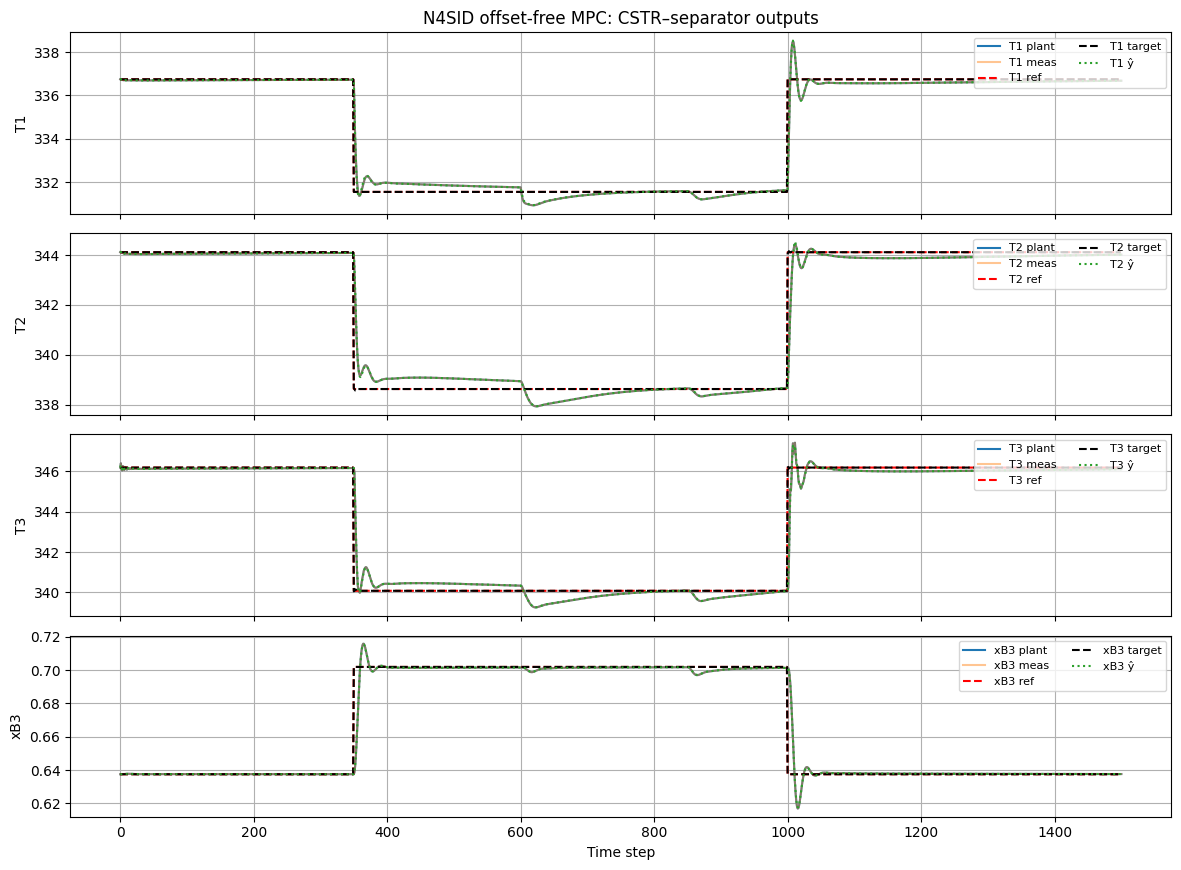

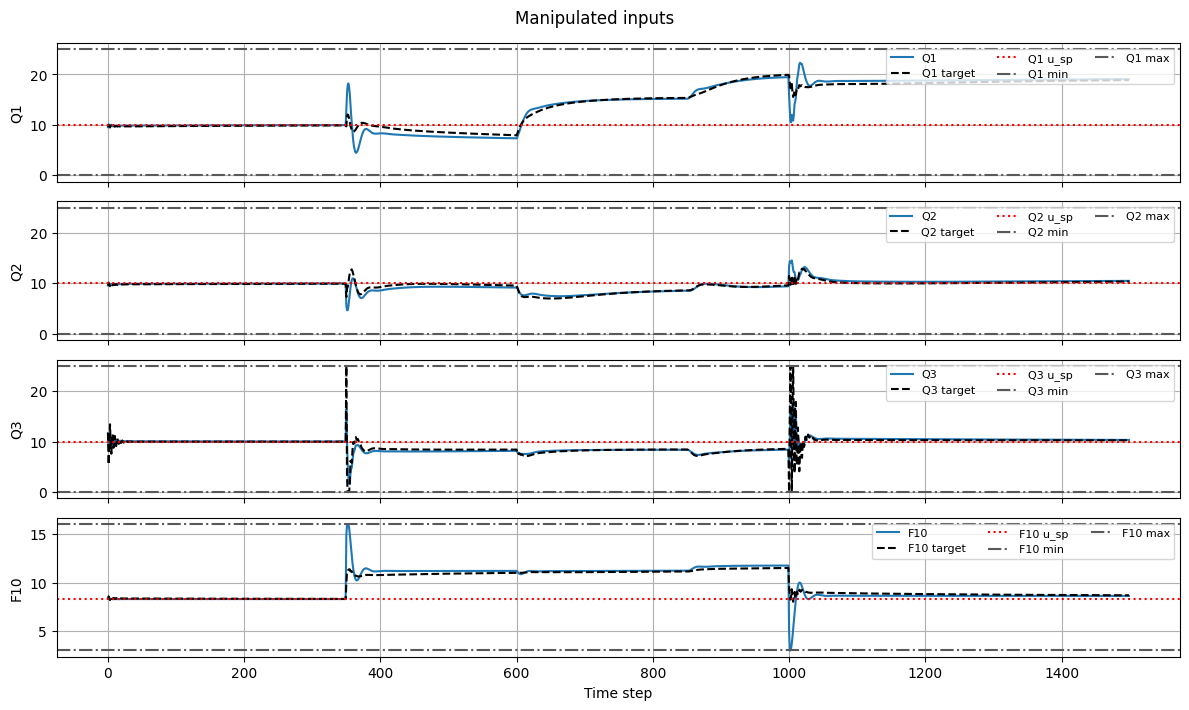

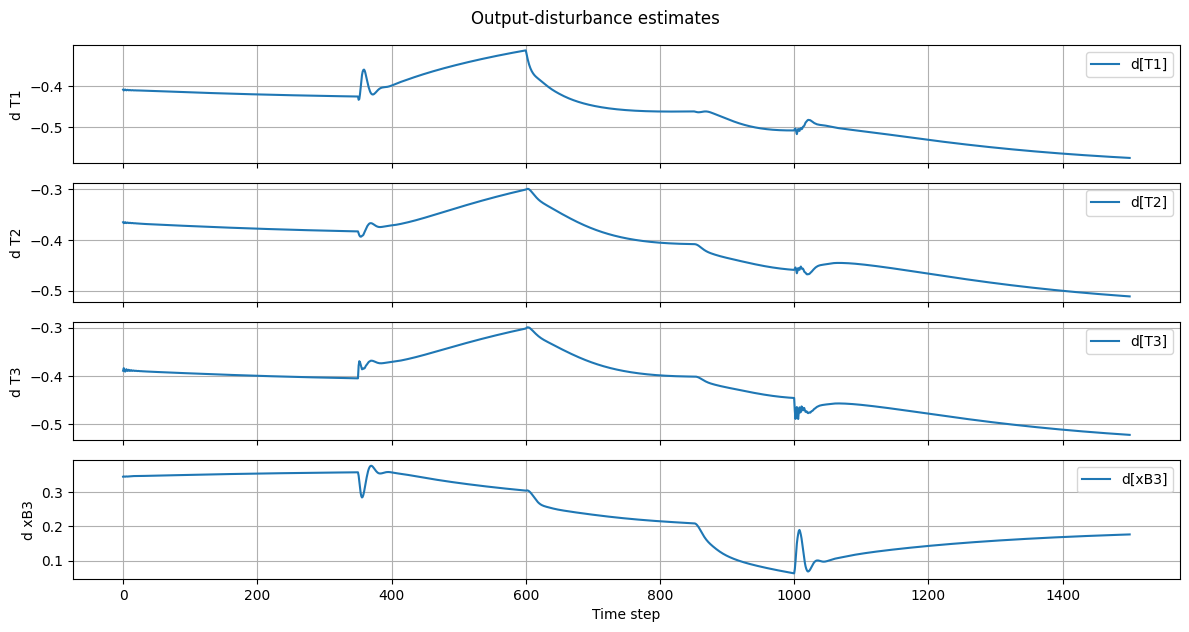

In [10]:
Qy, Qu, Qdu = loaded_setup["Qy"], loaded_setup["Qu"], loaded_setup["Qdu"]
objective_value = state_error_cost = control_increment_cost = control_setpoint_cost = 0.0
for k in range(sim_time):
    y_diff = y_sim[:, k] - reference[:, k]
    prev_u = u_sim[:, k - 1] if k > 0 else u_sim[:, k]
    u_diff = u_sim[:, k] - prev_u
    u_error = us_sim[:, k] - u_sim[:, k]
    y_term = float(y_diff.T @ Qy @ y_diff)
    u_term = float(u_diff.T @ Qdu @ u_diff)
    u_sp_term = float(u_error.T @ Qu @ u_error)
    state_error_cost += y_term
    control_increment_cost += u_term
    control_setpoint_cost += u_sp_term
    objective_value += y_term + u_term + u_sp_term

print(f"Closed-loop objective function value: {objective_value}")
print(f"  - State tracking term: {state_error_cost}")
print(f"  - Input increment term: {control_increment_cost}")
print(f"  - Input setpoint term: {control_setpoint_cost}")

ys_sim_ns = scaler.inverse_transform(ys_sim.T).T
us_sim_ns = scalerU.inverse_transform(us_sim.T).T
y_hat_ns = scaler.inverse_transform((C @ z_sim[:nz] + z_sim[nz:]).T).T

n_steps = sim_time
fig, axs = plt.subplots(ny, 1, figsize=(12, 2.2 * ny), sharex=True)
for i, name in enumerate(y_names):
    axs[i].plot(y_true_ns[i, :], label=f"{name} plant")
    axs[i].plot(y_sim_ns[i, :], alpha=0.45, label=f"{name} meas")
    axs[i].plot(reference_ns[i, :n_steps], "r--", label=f"{name} ref")
    axs[i].plot(ys_sim_ns[i, :n_steps], "k--", label=f"{name} target")
    axs[i].plot(y_hat_ns[i, :], ":", label=f"{name} ŷ")
    axs[i].set_ylabel(name)
    axs[i].grid(True)
    axs[i].legend(loc="upper right", ncol=2, fontsize=8)
axs[-1].set_xlabel("Time step")
axs[0].set_title("N4SID offset-free MPC: CSTR–separator outputs")
fig.tight_layout()

fig_u, axs_u = plt.subplots(nu, 1, figsize=(12, 1.8 * nu), sharex=True)
u_sp_ns = scalerU.inverse_transform(u_sp.reshape(1, -1))[0]
u_min_ns = np.asarray(loaded_setup["u_min_ns"], dtype=float).reshape(-1)
u_max_ns = np.asarray(loaded_setup["u_max_ns"], dtype=float).reshape(-1)
for i, name in enumerate(u_names):
    axs_u[i].plot(u_sim_ns[i, :], label=name)
    axs_u[i].plot(us_sim_ns[i, :], "k--", label=f"{name} target")
    axs_u[i].axhline(u_sp_ns[i], color="r", linestyle=":", label=f"{name} u_sp")
    axs_u[i].axhline(u_min_ns[i], color="0.35", linestyle="-.", label=f"{name} min")
    axs_u[i].axhline(u_max_ns[i], color="0.35", linestyle="-.", label=f"{name} max")
    axs_u[i].set_ylabel(name)
    axs_u[i].grid(True)
    axs_u[i].legend(loc="upper right", ncol=3, fontsize=8)
axs_u[-1].set_xlabel("Time step")
fig_u.suptitle("Manipulated inputs")
fig_u.tight_layout()

fig_d, axs_d = plt.subplots(nd, 1, figsize=(12, 1.6 * nd), sharex=True)
for i in range(nd):
    axs_d[i].plot(z_sim[nz + i, :], label=f"d[{y_names[i]}]")
    axs_d[i].set_ylabel(f"d {y_names[i]}")
    axs_d[i].grid(True)
    axs_d[i].legend()
axs_d[-1].set_xlabel("Time step")
fig_d.suptitle("Output-disturbance estimates")
fig_d.tight_layout()